In [5]:
import xarray as xr, numpy as np, matplotlib.pyplot as plt
import netCDF4 as nc

In [6]:
def extract_valid_tb_lat_lon(
    granule_path, 
    channel_index=12, 
    pass_direction="both"
):
    """Extract valid brightness temperature, latitude, and longitude from a granule."""
    with nc.Dataset(granule_path, 'r') as ds:
        bt_full = ds.groups['BT']['spectral_BT'][:]
        lat = ds.groups['Geometry']['latitude'][:]
        lon = ds.groups['Geometry']['longitude'][:]
        quality_raw = ds.groups['BT']['BT_quality_flag'][:]
        quality = quality_raw[:, :, channel_index] if quality_raw.ndim == 3 else quality_raw
        
        min_atrack = min(bt_full.shape[0], lat.shape[0], lon.shape[0], quality.shape[0])
        bt = bt_full[:min_atrack, :, channel_index]
        lat = lat[:min_atrack, :]
        lon = lon[:min_atrack, :]
        quality = quality[:min_atrack, :]

        valid_mask = (
            np.isfinite(bt) & np.isfinite(lat) & np.isfinite(lon)
            & np.isin(quality, [0, 1])
        )
        # Get wavelength
        wavelengths = ds.groups['Radiance']['wavelength'][:]  # [xtrack, spectral]
        mean_wavelength = wavelengths[:, channel_index].mean()

        # Filter by pass direction
        pass_type = ds['Geometry']['satellite_pass_type'][:]
        if pass_direction == "ascending":
            direction_mask = pass_type == 1
        elif pass_direction == "descending":
            direction_mask = pass_type == -1
        else:
            direction_mask = np.ones(pass_type.shape, dtype=bool)  # keep all

        # Apply direction mask along the first axis (atrack)
        lat = lat[direction_mask, :]
        lon = lon[direction_mask, :]
        bt = bt[direction_mask, :]
        valid_mask = valid_mask[direction_mask, :]

        return bt[valid_mask], lat[valid_mask], lon[valid_mask], mean_wavelength

In [7]:
granule_path = './test.nc'
ds = xr.load_dataset(granule_path, group = 'Radiance', engine='netcdf4')
geo = xr.load_dataset(granule_path, group = 'Geometry', engine='netcdf4')


In [40]:
wavelength = ds['wavelength'].isel(xtrack = 1)
spatial_radiance = ds['spectral_radiance'].isel(xtrack = 1, atrack = 4000)



In [ ]:
import os
granule_path = os.listdir('./data')[0]
ds = xr.load_dataset(f'./data/{granule_path}', group = 'Radiance', engine='netcdf4')
ds['wavelength'].plot()

In [67]:
geo

<xarray.Dataset> Size: 8MB
Dimensions:                      (atrack: 7678, xtrack: 8, UTC_parts: 7,
                                  FOV_vertices: 4)
Dimensions without coordinates: atrack, xtrack, UTC_parts, FOV_vertices
Data variables: (12/25)
    obs_ID                       (atrack, xtrack) float64 491kB 2.025e+16 ......
    ctime                        (atrack) datetime64[ns] 61kB 2025-11-17T13:2...
    ctime_minus_UTC              (atrack) timedelta64[ns] 61kB 00:00:05 ... 0...
    time_UTC_values              (atrack, UTC_parts) float32 215kB 2.025e+03 ...
    latitude                     (atrack, xtrack) float32 246kB -0.04688 ... ...
    longitude                    (atrack, xtrack) float32 246kB -147.4 ... -1...
    ...                           ...
    sat_solar_illumination_flag  (atrack) float32 31kB 0.0 0.0 0.0 ... 0.0 0.0
    geoloc_quality_bitflags      (atrack, xtrack) float32 246kB 0.0 0.0 ... 0.0
    maxintgz_verts_lat           (atrack, xtrack, FOV_vertices) float32 983kB ...
    maxintgz_verts_lon           (atrack, xtrack, FOV_vertices) float32 983kB ...
    orbit_phase_metric           (atrack) float32 31kB 0.01562 0.05469 ... 360.0
    satellite_pass_type          (atrack) float32 31kB 1.0 1.0 1.0 ... 1.0 1.0
Attributes:
    image_integration_duration_ms:  700.7
    solar_beta_angle_deg:           -49.27436065673828
    TAI_minus_ctime_at_epoch_s:     32.0
    start_granule_edge_ctime_s:     816700968.789042
    end_granule_edge_ctime_s:       816706653.216255

In [ ]:
import numpy as np
from scipy.interpolate import LinearNDInterpolator

# --- source coordinates ---
lat2d = geo['latitude'].values   # (atrack, xtrack)
lon2d = geo['longitude'].values  # (atrack, xtrack)

# --- define 0.25° target grid bounded by the data extent ---
lat_min = np.floor(np.nanmin(lat2d) * 4) / 4
lat_max = np.ceil(np.nanmax(lat2d) * 4) / 4
lon_min = np.floor(np.nanmin(lon2d) * 4) / 4
lon_max = np.ceil(np.nanmax(lon2d) * 4) / 4

lat_grid = np.arange(lat_min, lat_max + 1e-6, 0.25)
lon_grid = np.arange(lon_min, lon_max + 1e-6, 0.25)
lon_2d, lat_2d = np.meshgrid(lon_grid, lat_grid)       # (nlat, nlon)
target_pts = np.column_stack([lat_2d.ravel(), lon_2d.ravel()])

# --- flatten source points, keep only finite lat/lon ---
valid = np.isfinite(lat2d.ravel()) & np.isfinite(lon2d.ravel())
src_pts = np.column_stack([lat2d.ravel()[valid], lon2d.ravel()[valid]])

# --- flatten radiance arrays to (n_pts, spectral) ---
n_spec = ds.sizes['spectral']
rad_src = ds['spectral_radiance'].values.reshape(-1, n_spec)[valid]      # (n_valid, spectral)
unc_src = ds['spectral_radiance_unc'].values.reshape(-1, n_spec)[valid]

# --- build interpolators once (triangulation is shared across all spectral channels) ---
rad_interp = LinearNDInterpolator(src_pts, rad_src)
unc_interp = LinearNDInterpolator(src_pts, unc_src)


nlat, nlon = len(lat_grid), len(lon_grid)
rad_grid  = rad_interp(target_pts).reshape(nlat, nlon, n_spec).astype(np.float32)
unc_grid  = unc_interp(target_pts).reshape(nlat, nlon, n_spec).astype(np.float32)

# wavelength averaged over xtrack detectors → (spectral,)
wl_mean = ds['wavelength'].mean(dim='xtrack').values

# --- assemble output Dataset ---
ds_regrid = xr.Dataset(
    {
        'wavelength':            (['spectral'], wl_mean),
        'spectral_radiance':     (['lat', 'lon', 'spectral'], rad_grid),
        'spectral_radiance_unc': (['lat', 'lon', 'spectral'], unc_grid),
    },
    coords={
        'lat': (['lat'], lat_grid, {'units': 'degrees_north'}),
        'lon': (['lon'], lon_grid, {'units': 'degrees_east'}),
        'spectral': np.arange(n_spec),
    },
)

ds_regrid

<xarray.Dataset> Size: 486MB
Dimensions:                (spectral: 63, lat: 670, lon: 1440)
Coordinates:
  * spectral               (spectral) int64 504B 0 1 2 3 4 5 ... 58 59 60 61 62
  * lat                    (lat) float64 5kB -83.75 -83.5 -83.25 ... 83.25 83.5
  * lon                    (lon) float64 12kB -180.0 -179.8 ... 179.5 179.8
Data variables:
    wavelength             (spectral) float32 252B nan nan nan ... 51.9 52.66
    spectral_radiance      (lat, lon, spectral) float32 243MB nan nan ... nan
    spectral_radiance_unc  (lat, lon, spectral) float32 243MB nan nan ... nan

In [ ]:

# --- source coordinates ---
lat2d = geo['latitude'].values   # (atrack, xtrack)
lon2d = geo['longitude'].values  # (atrack, xtrack)

# --- define 0.25° target grid bounded by the data extent ---
lat_min = np.floor(np.nanmin(lat2d) * 4) / 4
lat_max = np.ceil(np.nanmax(lat2d) * 4) / 4
lon_min = np.floor(np.nanmin(lon2d) * 4) / 4
lon_max = np.ceil(np.nanmax(lon2d) * 4) / 4

lat_grid = np.arange(lat_min, lat_max + 1e-6, 0.25)
lon_grid = np.arange(lon_min, lon_max + 1e-6, 0.25)
lon_2d, lat_2d = np.meshgrid(lon_grid, lat_grid)       # (nlat, nlon)
target_pts = np.column_stack([lat_2d.ravel(), lon_2d.ravel()])

# --- flatten source points, keep only finite lat/lon ---
valid = np.isfinite(lat2d.ravel()) & np.isfinite(lon2d.ravel())
src_pts = np.column_stack([lat2d.ravel()[valid], lon2d.ravel()[valid]])

# --- flatten radiance arrays to (n_pts, spectral) ---
n_spec = ds.sizes['spectral']
rad_src = ds['spectral_radiance'].values.reshape(-1, n_spec)[valid]      # (n_valid, spectral)
unc_src = ds['spectral_radiance_unc'].values.reshape(-1, n_spec)[valid]

# --- binning approach: mean of all source points that fall into each 0.25° cell ---
# reuses lat_grid, lon_grid, rad_src, unc_src, valid, wl_mean from the cell above

lat_src = lat2d.ravel()[valid] #Flattened latitudes of valid source points
lon_src = lon2d.ravel()[valid] #Flattened longitudes of valid source points

nlat, nlon = len(lat_grid), len(lon_grid)

# integer grid indices for each source point
i_lat = np.floor((lat_src - lat_grid[0]) / 0.25).astype(int)
i_lon = np.floor((lon_src - lon_grid[0]) / 0.25).astype(int)
in_bounds = (i_lat >= 0) & (i_lat < nlat) & (i_lon >= 0) & (i_lon < nlon)
i_flat = i_lat[in_bounds] * nlon + i_lon[in_bounds]   # 1-D index into (nlat*nlon)

rad_in = rad_src[in_bounds]   # (n_in, spectral)
unc_in = unc_src[in_bounds]

# zero out NaNs before accumulating; track valid counts per spectral channel separately
rad_vals = np.where(np.isfinite(rad_in), rad_in, 0.0)
unc_vals = np.where(np.isfinite(unc_in), unc_in, 0.0)
rad_cnt  = np.isfinite(rad_in).astype(np.int32)
unc_cnt  = np.isfinite(unc_in).astype(np.int32)

rad_sum     = np.zeros((nlat * nlon, n_spec), dtype=np.float64)
unc_sum     = np.zeros((nlat * nlon, n_spec), dtype=np.float64)
rad_cnt_arr = np.zeros((nlat * nlon, n_spec), dtype=np.int32)
unc_cnt_arr = np.zeros((nlat * nlon, n_spec), dtype=np.int32)

np.add.at(rad_sum,     i_flat, rad_vals)
np.add.at(unc_sum,     i_flat, unc_vals)
np.add.at(rad_cnt_arr, i_flat, rad_cnt)
np.add.at(unc_cnt_arr, i_flat, unc_cnt)

with np.errstate(invalid='ignore'):
    rad_bin = np.where(rad_cnt_arr > 0, rad_sum / rad_cnt_arr, np.nan).reshape(nlat, nlon, n_spec).astype(np.float32)
    unc_bin = np.where(unc_cnt_arr > 0, unc_sum / unc_cnt_arr, np.nan).reshape(nlat, nlon, n_spec).astype(np.float32)

# number of source pixels that contributed to each grid cell
pt_count = np.zeros(nlat * nlon, dtype=np.int32)
np.add.at(pt_count, i_flat, 1)

ds_binned = xr.Dataset(
    {
        'wavelength':            (['spectral'], wl_mean),
        'spectral_radiance':     (['lat', 'lon', 'spectral'], rad_bin),
        'spectral_radiance_unc': (['lat', 'lon', 'spectral'], unc_bin),
        'count':                 (['lat', 'lon'], pt_count.reshape(nlat, nlon)),
    },
    coords={
        'lat': (['lat'], lat_grid, {'units': 'degrees_north'}),
        'lon': (['lon'], lon_grid, {'units': 'degrees_east'}),
        'spectral': np.arange(n_spec),
    },
)

ds_binned

<xarray.Dataset> Size: 490MB
Dimensions:                (spectral: 63, lat: 670, lon: 1440)
Coordinates:
  * spectral               (spectral) int64 504B 0 1 2 3 4 5 ... 58 59 60 61 62
  * lat                    (lat) float64 5kB -83.75 -83.5 -83.25 ... 83.25 83.5
  * lon                    (lon) float64 12kB -180.0 -179.8 ... 179.5 179.8
Data variables:
    wavelength             (spectral) float32 252B nan nan nan ... 51.9 52.66
    spectral_radiance      (lat, lon, spectral) float32 243MB nan nan ... nan
    spectral_radiance_unc  (lat, lon, spectral) float32 243MB nan nan ... nan
    count                  (lat, lon) int32 4MB 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0

In [72]:
rad_sum

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(964800, 63))

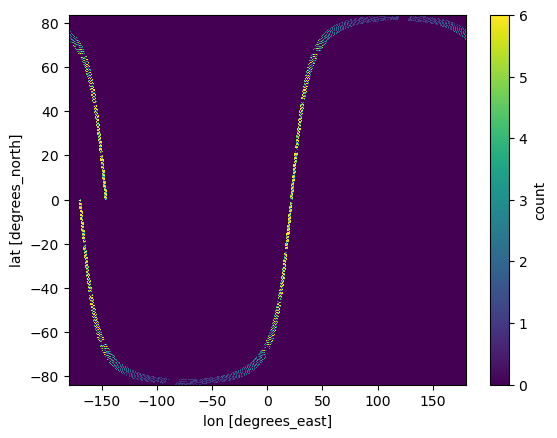

In [53]:
ds_binned['count'].plot()